# Family-State Belief Point Cloud

This notebook constructs and visualizes the active-set family-level belief-state point cloud for Universe B. Each timestamp is represented by a family-level vector containing active-market probability summaries by broad family.

This stage is intentionally only point-cloud construction and visualization. It does **not** compute persistent homology.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src" / "point_cloud_visualization.py").exists():
            return candidate
        nested = candidate / "polymarket_topology"
        if (nested / "src" / "point_cloud_visualization.py").exists():
            return nested
    raise FileNotFoundError("Could not locate polymarket_topology project root")

ROOT = find_project_root(Path.cwd().resolve())
sys.path.append(str(ROOT / "src"))

from point_cloud_visualization import run_all, preprocess_family_state

PROCESSED = ROOT / "data" / "processed"
FIGURES = PROCESSED / "figures" / "point_cloud"

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
plt.style.use("default")

/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Run Or Load Point-Cloud Artifacts

Set `RUN_POINT_CLOUD = True` to regenerate the matrix, PCA projection, optional UMAP projection, figures, and markdown summary.

In [2]:
RUN_POINT_CLOUD = False

if RUN_POINT_CLOUD:
    result = run_all(
        PROCESSED / "candidate_universe_markets.parquet",
        PROCESSED / "prices_long.parquet",
        PROCESSED / "universe_b_macro_crypto_panel.parquet",
        PROCESSED,
    )
    family_state = result["family_state"]
    feature_state = result["feature_state"]
    pca_coords = result["pca_coords"]
    umap_coords = result["umap_coords"]
    pca = result["pca"]
    summary_text = result["summary"]
else:
    family_state = pd.read_parquet(PROCESSED / "family_state_matrix.parquet")
    if "timestamp" in family_state.columns:
        family_state = family_state.set_index("timestamp")
    family_state.index = pd.to_datetime(family_state.index, utc=True)
    feature_state, scaled, _imputer, _scaler, _cols = preprocess_family_state(family_state)
    pca_coords = pd.read_parquet(PROCESSED / "family_state_point_cloud_pca3.parquet")
    umap_path = PROCESSED / "family_state_point_cloud_umap3.parquet"
    umap_coords = pd.read_parquet(umap_path) if umap_path.exists() else None
    summary_text = (PROCESSED / "family_state_point_cloud_summary.md").read_text(encoding="utf-8")

print("family_state", family_state.shape)
print("feature_state", feature_state.shape)
print("pca_coords", pca_coords.shape)
print("umap available", umap_coords is not None)

family_state (14464, 24)
feature_state (14464, 23)
pca_coords (14464, 7)
umap available False


## Family-State Matrix

In [3]:
matrix_summary = pd.DataFrame([{
    "timestamps": len(family_state),
    "raw_features": family_state.shape[1],
    "usable_features": feature_state.shape[1],
    "missingness_before_preprocessing": family_state.isna().mean().mean(),
    "missingness_after_preprocessing": 0.0,
    "timestamp_min": family_state.index.min(),
    "timestamp_max": family_state.index.max(),
}])
display(matrix_summary)
display(family_state.head())

feature_missing = family_state.isna().mean().sort_values(ascending=False).rename("missingness").reset_index().rename(columns={"index": "feature"})
display(feature_missing.head(20))

,timestamps,raw_features,usable_features,missingness_before_preprocessing,missingness_after_preprocessing,timestamp_min,timestamp_max
0,14464,24,23,0.130053,0.0,2024-08-06 17:00:00+00:00,2026-04-01 08:00:00+00:00


,crypto_btc__mean,crypto_btc__median,crypto_btc__std,crypto_btc__count,crypto_eth__mean,crypto_eth__median,crypto_eth__std,crypto_eth__count,crypto_microstrategy__mean,crypto_microstrategy__median,crypto_microstrategy__std,crypto_microstrategy__count,crypto_policy__mean,crypto_policy__median,crypto_policy__std,crypto_policy__count,crypto_regulation__mean,crypto_regulation__median,crypto_regulation__std,crypto_regulation__count,macro_fed_rates__mean,macro_fed_rates__median,macro_fed_rates__std,macro_fed_rates__count
timestamp,,,,,,,,,,,,,,,,,,,,,,,,
2024-08-06 17:00:00+00:00,0.11375,0.11375,0.08125,2.0,0.060,0.060,0.0,1.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,0.283225,0.22150,0.239402,20.0
2024-08-06 18:00:00+00:00,0.11900,0.11900,0.08600,2.0,0.060,0.060,0.0,1.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,0.254725,0.19500,0.230087,20.0
2024-08-06 19:00:00+00:00,0.12000,0.12000,0.08500,2.0,0.065,0.065,0.0,1.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,0.250225,0.17825,0.228640,20.0
2024-08-06 20:00:00+00:00,0.12000,0.12000,0.08500,2.0,0.065,0.065,0.0,1.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,0.250050,0.16550,0.228658,20.0
2024-08-06 21:00:00+00:00,0.12250,0.12250,0.08750,2.0,0.065,0.065,0.0,1.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,0.252450,0.17325,0.228807,20.0


,feature,missingness
0,crypto_regulation__median,0.920147
1,crypto_regulation__mean,0.920147
2,crypto_policy__mean,0.302406
3,crypto_policy__median,0.302406
4,crypto_microstrategy__median,0.244054
5,crypto_microstrategy__mean,0.244054
6,crypto_eth__mean,0.047082
7,crypto_eth__median,0.047082
8,crypto_btc__median,0.046944
9,crypto_btc__mean,0.046944


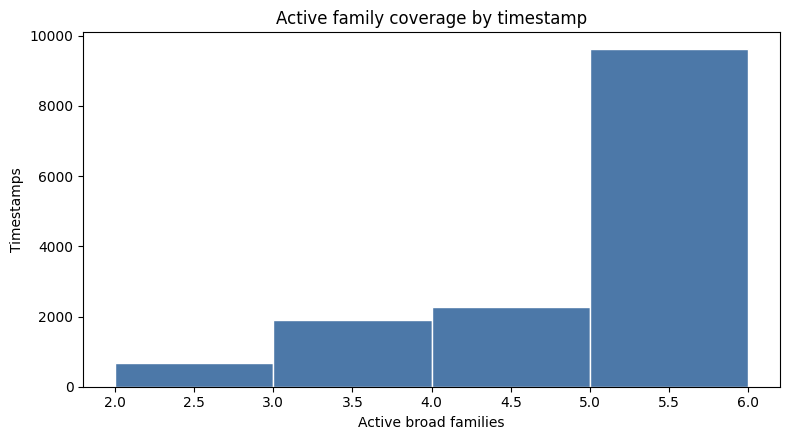

count    14464.00000
mean         4.43992
std          0.88882
min          2.00000
25%          4.00000
50%          5.00000
75%          5.00000
max          5.00000
dtype: float64

In [4]:
count_cols = [col for col in family_state.columns if col.endswith("__count")]
active_family_count = (family_state[count_cols].fillna(0) > 0).sum(axis=1)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(active_family_count, bins=range(int(active_family_count.min()), int(active_family_count.max()) + 2), color="#4C78A8", edgecolor="white")
ax.set_title("Active family coverage by timestamp")
ax.set_xlabel("Active broad families")
ax.set_ylabel("Timestamps")
plt.tight_layout()
plt.show()
active_family_count.describe()

## PCA 3D Projection Coordinates

In [5]:
display(pca_coords.head())
print(pca_coords[["PC1", "PC2", "PC3", "active_market_count", "active_family_count", "average_market_probability"]].describe().to_string())

,timestamp,PC1,PC2,PC3,active_market_count,active_family_count,average_market_probability
0,2024-08-06 17:00:00+00:00,-0.608507,-3.712675,0.485535,23,3,0.258783
1,2024-08-06 18:00:00+00:00,-0.359590,-3.474347,0.277921,23,3,0.234457
2,2024-08-06 19:00:00+00:00,-0.296146,-3.356358,0.182828,23,3,0.230848
3,2024-08-06 20:00:00+00:00,-0.255539,-3.303691,0.136618,23,3,0.230696
4,2024-08-06 21:00:00+00:00,-0.316534,-3.336340,0.146827,23,3,0.233000


                PC1           PC2           PC3  active_market_count  active_family_count  average_market_probability
count  1.446400e+04  1.446400e+04  1.446400e+04         14464.000000          14464.00000                14464.000000
mean  -2.515196e-16 -1.886397e-16  3.143994e-17            36.848659              4.43992                    0.170084
std    2.678340e+00  2.238694e+00  1.579605e+00            14.344715              0.88882                    0.053590
min   -8.824323e+00 -3.800444e+00 -1.404094e+01            17.000000              2.00000                    0.071095
25%   -2.483493e+00 -2.065218e+00 -1.003977e+00            23.000000              4.00000                    0.122657
50%    1.028127e-01  2.602120e-01  1.228578e-02            34.000000              5.00000                    0.173359
75%    2.253476e+00  1.923532e+00  7.619513e-01            48.000000              5.00000                    0.208681
max    5.460679e+00  5.038036e+00  6.156021e+00         

## Saved Visualizations

/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/data/processed/figures/point_cloud/pca3_scatter.png


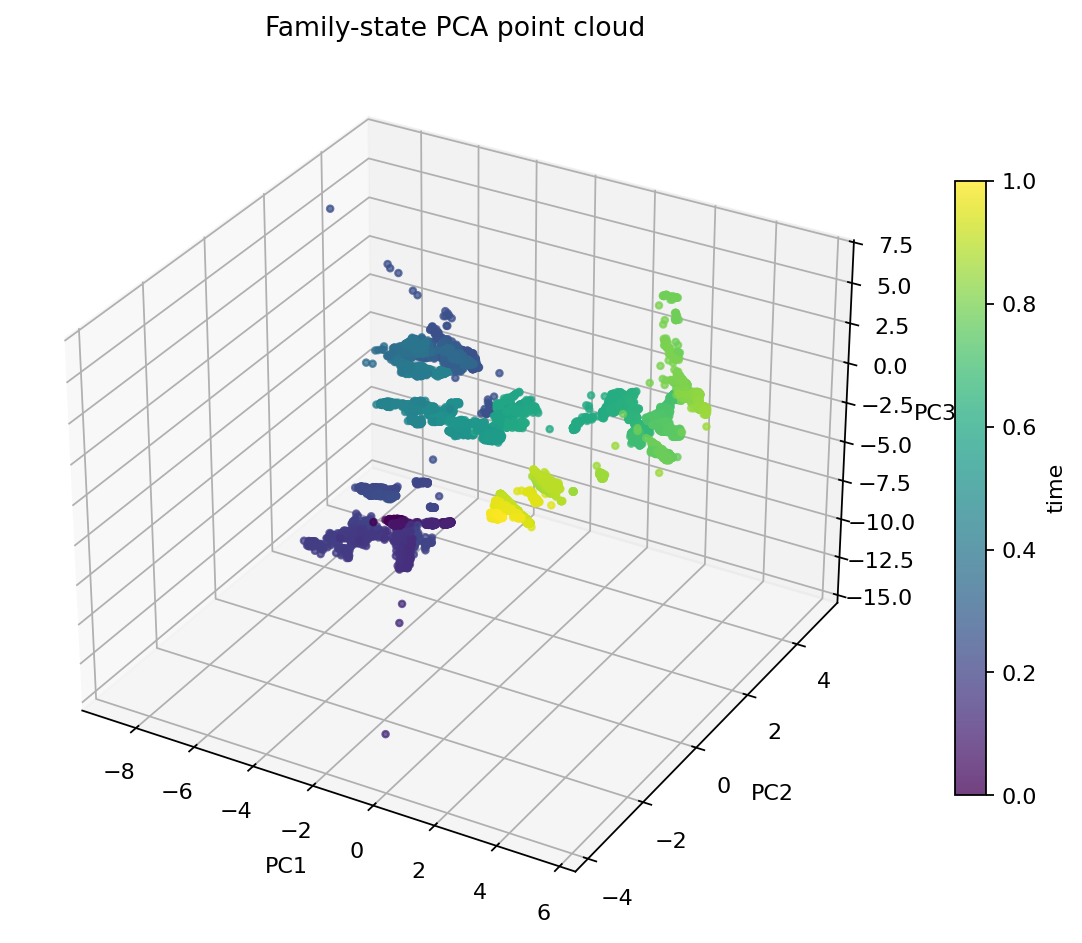

/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/data/processed/figures/point_cloud/pca3_trajectory.png


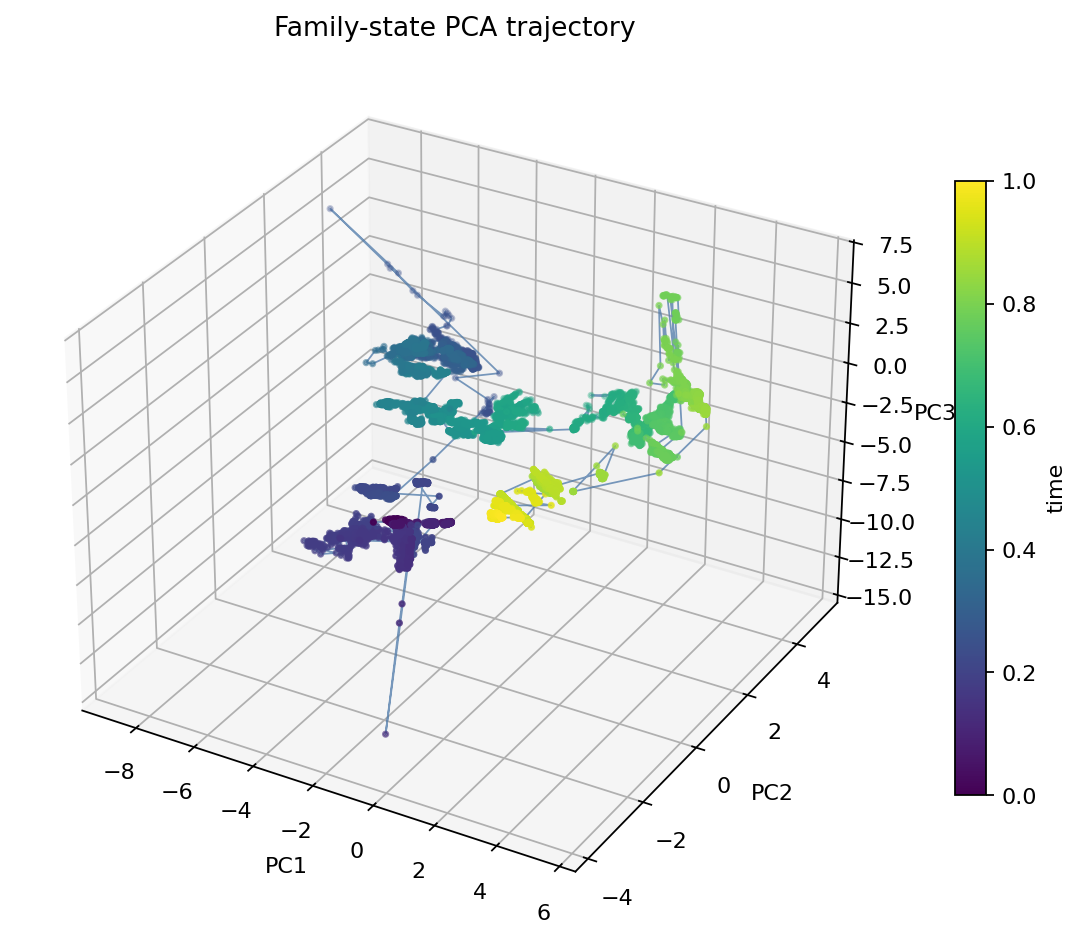

/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/data/processed/figures/point_cloud/pca2_scatter.png


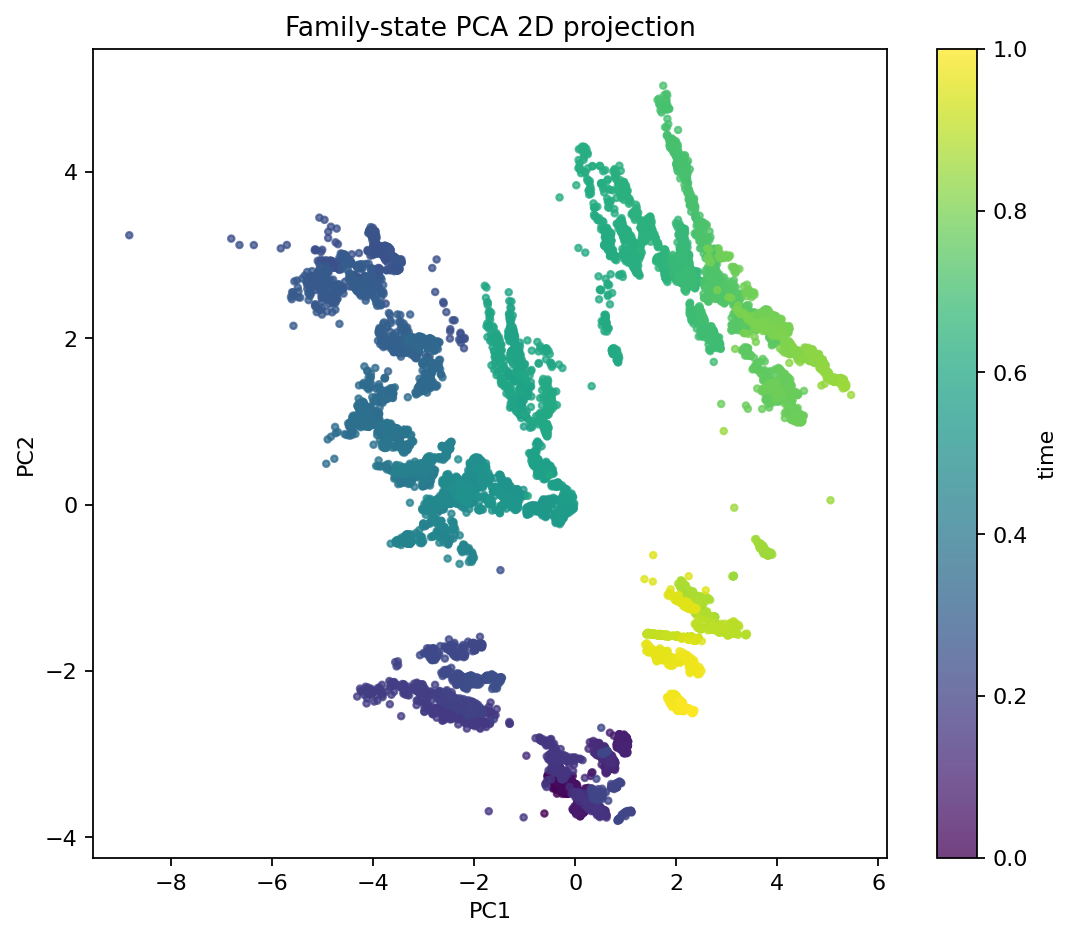

/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/data/processed/figures/point_cloud/pca_explained_variance_first10.png


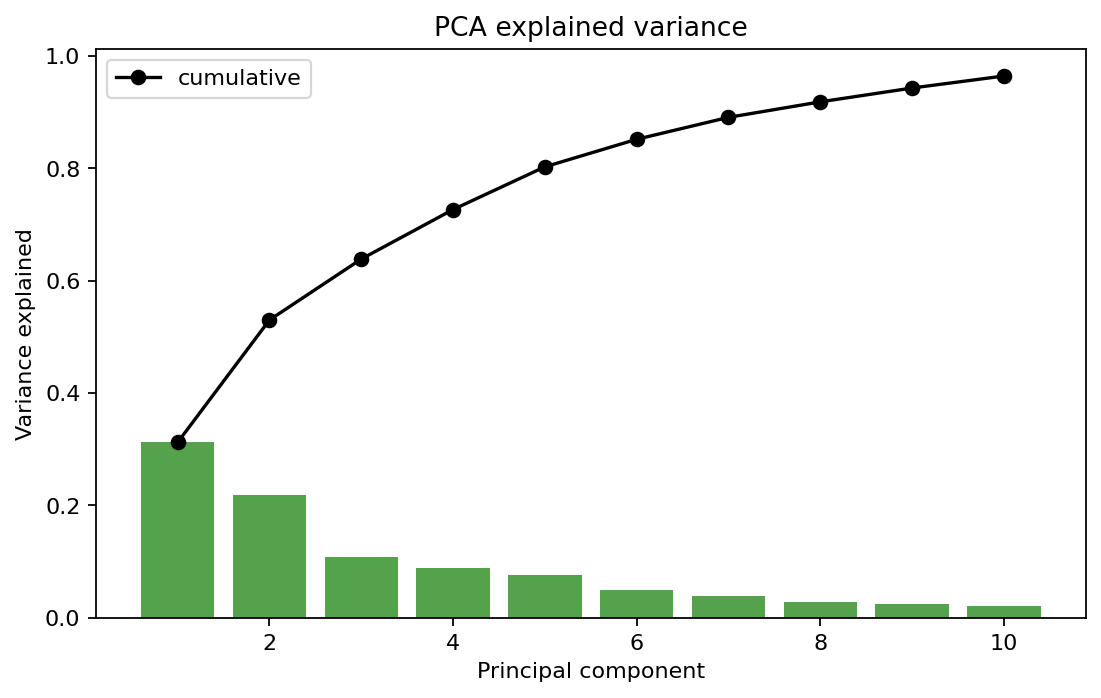

Skipped/missing: /Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/data/processed/figures/point_cloud/umap3_scatter.png


In [6]:
figure_files = [
    "pca3_scatter.png",
    "pca3_trajectory.png",
    "pca2_scatter.png",
    "pca_explained_variance_first10.png",
    "umap3_scatter.png",
]
for name in figure_files:
    path = FIGURES / name
    if path.exists():
        print(path)
        display(Image(filename=str(path)))
    else:
        print(f"Skipped/missing: {path}")

## UMAP Coordinates

In [7]:
if umap_coords is not None:
    display(umap_coords.head())
else:
    print("UMAP coordinates were not generated because umap-learn is not installed in this environment.")

UMAP coordinates were not generated because umap-learn is not installed in this environment.


## Summary

In [8]:
print(summary_text)

FAMILY-STATE POINT CLOUD SUMMARY

- number of timestamps: 14,464
- number of family-state features: 23
- missingness before preprocessing: 0.1301
- missingness after preprocessing: 0.0000
- active-family coverage: min 2, median 5, mean 4.44, max 5
- PCA explained variance PC1: 0.3119
- PCA explained variance PC2: 0.2179
- PCA explained variance PC3: 0.1085
- cumulative variance explained by 3 PCs: 0.6382
- UMAP status: UMAP skipped because umap-learn is not installed.

3D visualization diagnostics:
- clustering: yes; best k-means silhouette over k=2..5 is 0.405
- trajectory structure: yes; median step 0.035, p95 step 0.220
- loops or cycles: not obvious from PCA3 start/end geometry
- regime shifts: possible
- obvious outliers: yes; p99-radius outlier count 145

Interpretation:
The family-level belief-state cloud is structured enough to justify persistent homology if the goal is to test whether topology captures non-linear trajectory/regime information beyond PCA. The first three PCs ar